<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

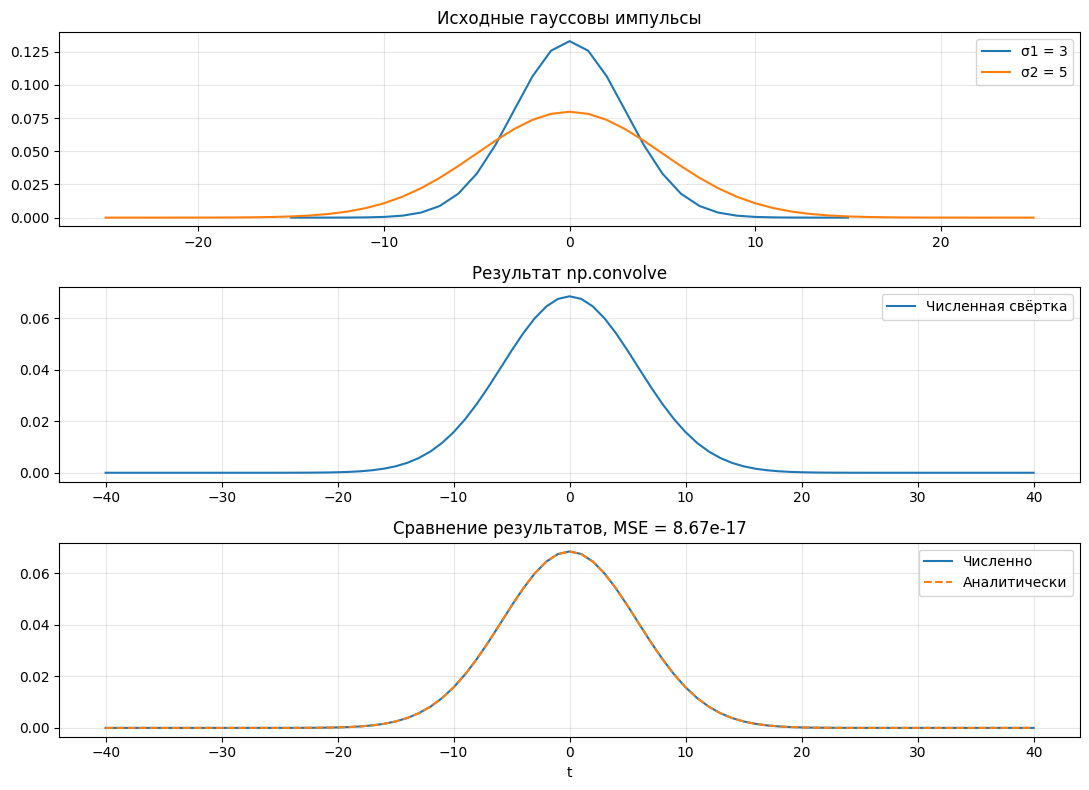

Суммарное σ = 5.831
MSE = 8.67e-17


In [2]:
# Задание 1
sigma1, sigma2 = 3, 5

def gaussian_samples(sigma):
    half = int(5 * sigma)
    t = np.arange(-half, half + 1)
    values = np.exp(-(t**2) / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)
    return t, values

t1, g1 = gaussian_samples(sigma1)
t2, g2 = gaussian_samples(sigma2)

conv_numeric = np.convolve(g1, g2, mode='full')
t_conv = np.arange(t1[0] + t2[0], t1[-1] + t2[-1] + 1)

sigma_sum = np.sqrt(sigma1**2 + sigma2**2)
conv_analytic = np.exp(-(t_conv**2) / (2 * sigma_sum**2)) / (np.sqrt(2 * np.pi) * sigma_sum)

mse = np.mean((conv_numeric - conv_analytic) ** 2)

plt.figure(figsize=(11, 8))

plt.subplot(3, 1, 1)
plt.plot(t1, g1, label=f'σ1 = {sigma1}')
plt.plot(t2, g2, label=f'σ2 = {sigma2}')
plt.title('Исходные гауссовы импульсы')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_conv, conv_numeric, label='Численная свёртка')
plt.title('Результат np.convolve')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_conv, conv_numeric, label='Численно')
plt.plot(t_conv, conv_analytic, '--', label='Аналитически')
plt.title(f'Сравнение результатов, MSE = {mse:.2e}')
plt.xlabel('t')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f'Суммарное σ = {sigma_sum:.3f}')
print(f'MSE = {mse:.2e}')

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении σ итоговая свёртка расширяется по оси времени и становится более сглаженной. 
Пик при этом становится ниже, потому что энергия распределяется по более широкому интервалу.

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

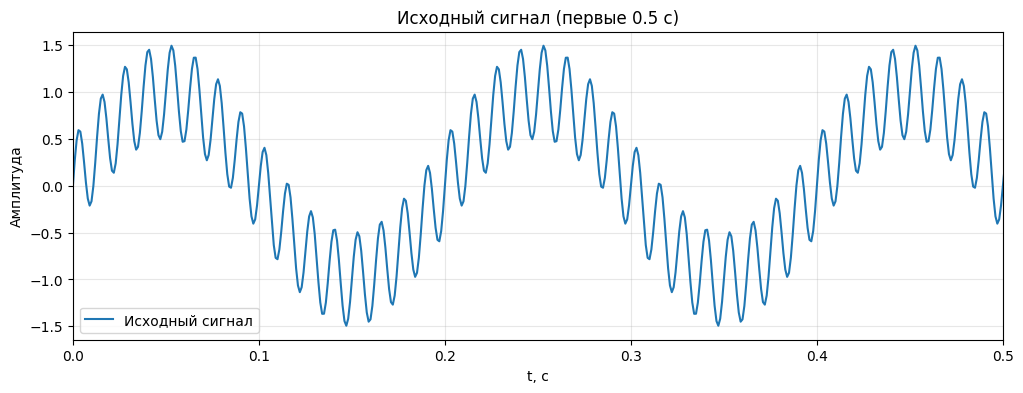

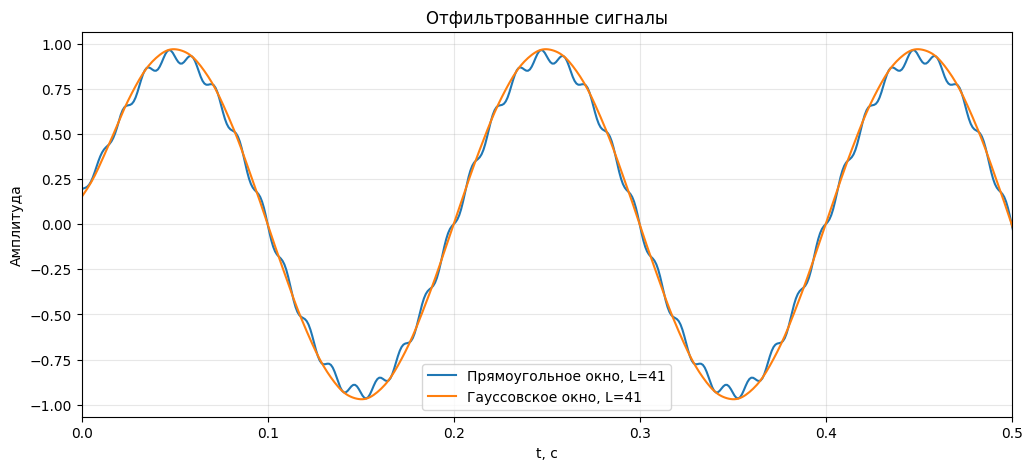

L | Окно            | A(5 Гц) | A(80 Гц) | Сохранено 5 Гц (%) | Сохранено 80 Гц (%)
11 | Прямоугольное   |  0.9951 |   0.0678 |             99.51 |              13.57
11 | Гауссовское     |  0.9978 |   0.2804 |             99.78 |              56.07
21 | Прямоугольное   |  0.9822 |   0.0800 |             98.22 |              16.00
21 | Гауссовское     |  0.9922 |   0.0502 |             99.22 |              10.05
41 | Прямоугольное   |  0.9330 |   0.0367 |             93.30 |               7.33
41 | Гауссовское     |  0.9704 |   0.0005 |             97.04 |               0.09
81 | Прямоугольное   |  0.7542 |   0.0254 |             75.42 |               5.08
81 | Гауссовское     |  0.8891 |   0.0028 |             88.91 |               0.55


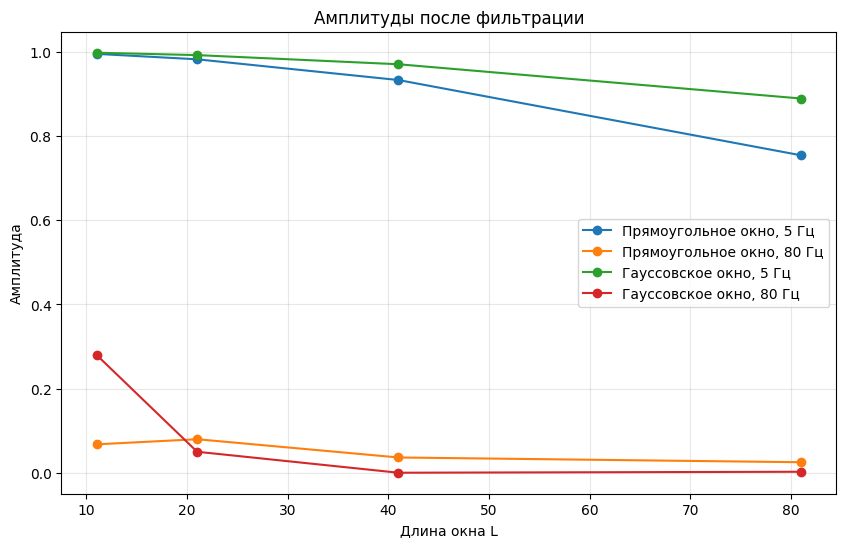

In [7]:
# Задание 2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
T = 2
t = np.arange(0, T, 1 / fs)

# 1. Исходный сигнал: 5 Гц + 80 Гц
f1, A1 = 5, 1.0
f2, A2 = 80, 0.5
x = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

# Длины окон из задания
window_lengths = [11, 21, 41, 81]

def make_rect_window(L):
    w = signal.windows.boxcar(L)
    return w / np.sum(w)

def make_gauss_window(L):
    w = signal.windows.gaussian(L, std=L / 5)
    return w / np.sum(w)

def get_fft_amplitude(sig, freq, fs):
    n = len(sig)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    spectrum = np.abs(np.fft.rfft(sig)) * 2 / n
    idx = np.argmin(np.abs(freqs - freq))
    return spectrum[idx]

results = []

# 2–4. Окна, свёртка и измерение амплитуд
for L in window_lengths:
    rect_window = make_rect_window(L)
    gauss_window = make_gauss_window(L)

    y_rect = np.convolve(x, rect_window, mode='same')
    y_gauss = np.convolve(x, gauss_window, mode='same')

    rect_amp_5 = get_fft_amplitude(y_rect, 5, fs)
    rect_amp_80 = get_fft_amplitude(y_rect, 80, fs)

    gauss_amp_5 = get_fft_amplitude(y_gauss, 5, fs)
    gauss_amp_80 = get_fft_amplitude(y_gauss, 80, fs)

    results.append({
        'L': L,
        'window': 'Прямоугольное',
        'A5': rect_amp_5,
        'A80': rect_amp_80,
        'keep5': rect_amp_5 / A1 * 100,
        'keep80': rect_amp_80 / A2 * 100
    })

    results.append({
        'L': L,
        'window': 'Гауссовское',
        'A5': gauss_amp_5,
        'A80': gauss_amp_80,
        'keep5': gauss_amp_5 / A1 * 100,
        'keep80': gauss_amp_80 / A2 * 100
    })

# 5. Графики для L = 41
L_view = 41
rect_window = make_rect_window(L_view)
gauss_window = make_gauss_window(L_view)

y_rect = np.convolve(x, rect_window, mode='same')
y_gauss = np.convolve(x, gauss_window, mode='same')

# График 1 — исходный сигнал
plt.figure(figsize=(12, 4))
plt.plot(t, x, label='Исходный сигнал')
plt.xlim(0, 0.5)
plt.title('Исходный сигнал (первые 0.5 с)')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# График 2 — отфильтрованные сигналы
plt.figure(figsize=(12, 5))
plt.plot(t, y_rect, label=f'Прямоугольное окно, L={L_view}')
plt.plot(t, y_gauss, label=f'Гауссовское окно, L={L_view}')
plt.xlim(0, 0.5)
plt.title('Отфильтрованные сигналы')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 6. Таблица амплитуд
print('L | Окно            | A(5 Гц) | A(80 Гц) | Сохранено 5 Гц (%) | Сохранено 80 Гц (%)')
for row in results:
    print(f"{row['L']:>2} | {row['window']:<15} | {row['A5']:>7.4f} | {row['A80']:>8.4f} | {row['keep5']:>17.2f} | {row['keep80']:>18.2f}")

# 7. График зависимости амплитуд от длины окна
L_vals = [row['L'] for row in results if row['window'] == 'Прямоугольное']
rect_5 = [row['A5'] for row in results if row['window'] == 'Прямоугольное']
rect_80 = [row['A80'] for row in results if row['window'] == 'Прямоугольное']

gauss_5 = [row['A5'] for row in results if row['window'] == 'Гауссовское']
gauss_80 = [row['A80'] for row in results if row['window'] == 'Гауссовское']

plt.figure(figsize=(10, 6))
plt.plot(L_vals, rect_5, marker='o', label='Прямоугольное окно, 5 Гц')
plt.plot(L_vals, rect_80, marker='o', label='Прямоугольное окно, 80 Гц')
plt.plot(L_vals, gauss_5, marker='o', label='Гауссовское окно, 5 Гц')
plt.plot(L_vals, gauss_80, marker='o', label='Гауссовское окно, 80 Гц')

plt.title('Амплитуды после фильтрации')
plt.xlabel('Длина окна L')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

- Гауссовское окно показывает более сильное подавление высокочастотной составляющей.
Это видно по тому, что амплитуда на 80 Гц для него уменьшается быстрее, чем для прямоугольного при одинаковом L.
- для гауссовского окна подавление до уровня примерно 10% достигается уже при длине около L ≈ 21–41,
для прямоугольного окна требуется большее значение L, и даже при L = 81 подавление остаётся менее выраженным. Таким образом, гауссовское окно достигает нужного уровня подавления при меньшей длине.
- При увеличении длины окна фильтрация становится более «жёсткой», что приводит не только к подавлению высокой частоты, но и к снижению амплитуды полезного сигнала (5 Гц).
- Снижение более чем на 10% наблюдается:
    - для прямоугольного окна примерно при L ≥ 81,
    - для гауссовского окна эффект проявляется слабее и происходит при больших длинах.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

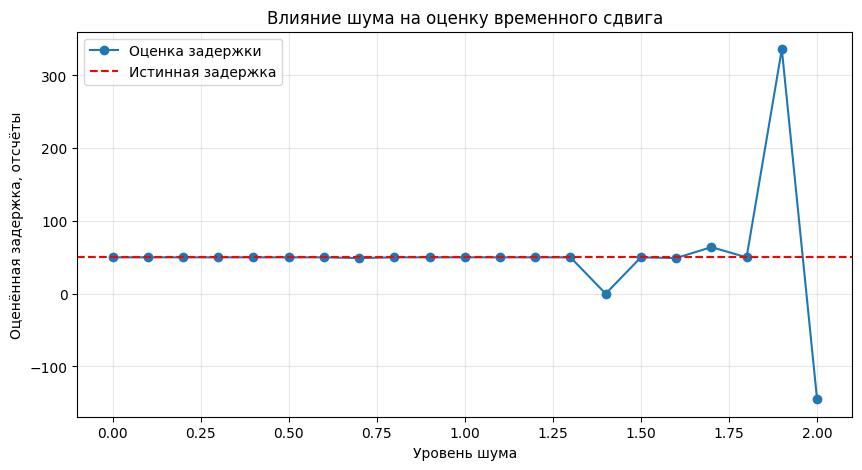

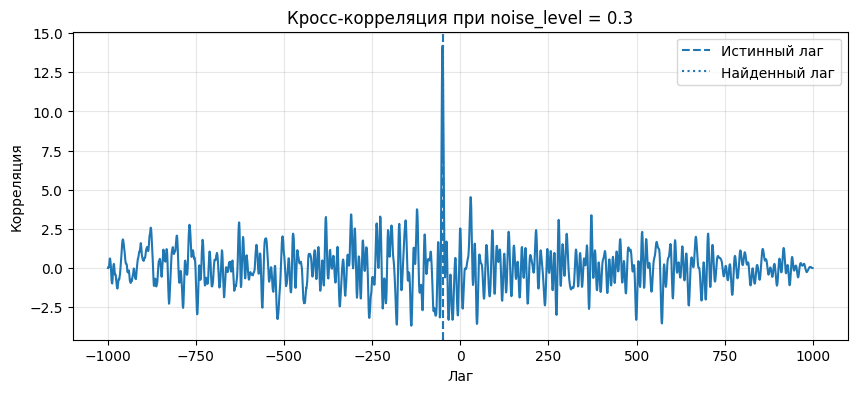

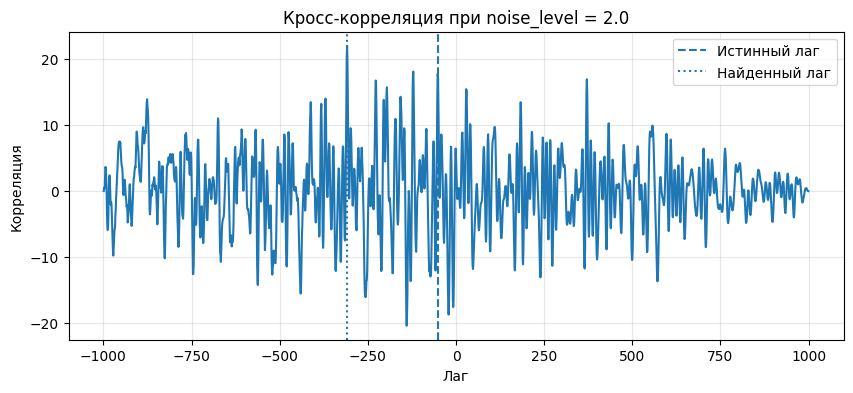

noise_level | estimated_delay | error
       0.0 |              50 |     0
       0.1 |              50 |     0
       0.2 |              50 |     0
       0.3 |              50 |     0
       0.4 |              50 |     0
       0.5 |              50 |     0
       0.6 |              50 |     0
       0.7 |              49 |     1
       0.8 |              50 |     0
       0.9 |              50 |     0
       1.0 |              50 |     0
       1.1 |              50 |     0
       1.2 |              50 |     0
       1.3 |              50 |     0
       1.4 |               0 |    50
       1.5 |              50 |     0
       1.6 |              49 |     1
       1.7 |              64 |    14
       1.8 |              50 |     0
       1.9 |             336 |   286
       2.0 |            -145 |   195


In [8]:
# Задание 3
np.random.seed(42)

fs = 1000
t = np.arange(0, 1, 1 / fs)

freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.2, 1.0, 100)

x = np.sum([a * np.sin(2 * np.pi * f * t) for a, f in zip(amps, freqs)], axis=0)
x = x / np.max(np.abs(x))

true_delay = 50

y_clean = np.zeros_like(x)
y_clean[true_delay:] = x[:-true_delay]

noise_levels = np.linspace(0, 2, 21)
estimated_delays = []
errors = []

for noise_level in noise_levels:
    y = y_clean + noise_level * np.random.randn(len(x))
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    estimated_delay = -lags[np.argmax(corr)]
    estimated_delays.append(estimated_delay)
    errors.append(abs(estimated_delay - true_delay))

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, estimated_delays, 'o-', label='Оценка задержки')
plt.axhline(true_delay, color='r', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Оценённая задержка, отсчёты')
plt.title('Влияние шума на оценку временного сдвига')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

for noise_level in [0.3, 2.0]:
    np.random.seed(42)
    y = y_clean + noise_level * np.random.randn(len(x))
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    estimated_delay = -lags[np.argmax(corr)]

    plt.figure(figsize=(10, 4))
    plt.plot(lags, corr)
    plt.axvline(-true_delay, linestyle='--', label='Истинный лаг')
    plt.axvline(-estimated_delay, linestyle=':', label='Найденный лаг')
    plt.title(f'Кросс-корреляция при noise_level = {noise_level}')
    plt.xlabel('Лаг')
    plt.ylabel('Корреляция')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

print('noise_level | estimated_delay | error')
for nl, est, err in zip(noise_levels, estimated_delays, errors):
    print(f'{nl:>10.1f} | {est:>15} | {err:>5}')

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

- С ростом шума точность оценки ухудшается, максимум корреляции становится менее выраженным.
Ошибка более 10% появляется примерно при noise_level ≈ 1.4.
При этом же уровне оценка может резко сбиваться и становиться близкой к 0.
- При большом шуме появляются случайные совпадения в сигналах, из-за чего возникают ложные пики корреляции, которые могут превышать настоящий максимум.

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

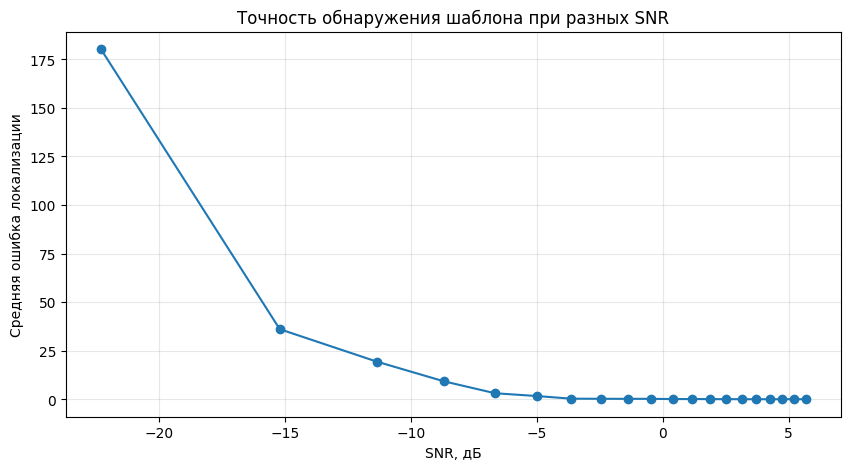

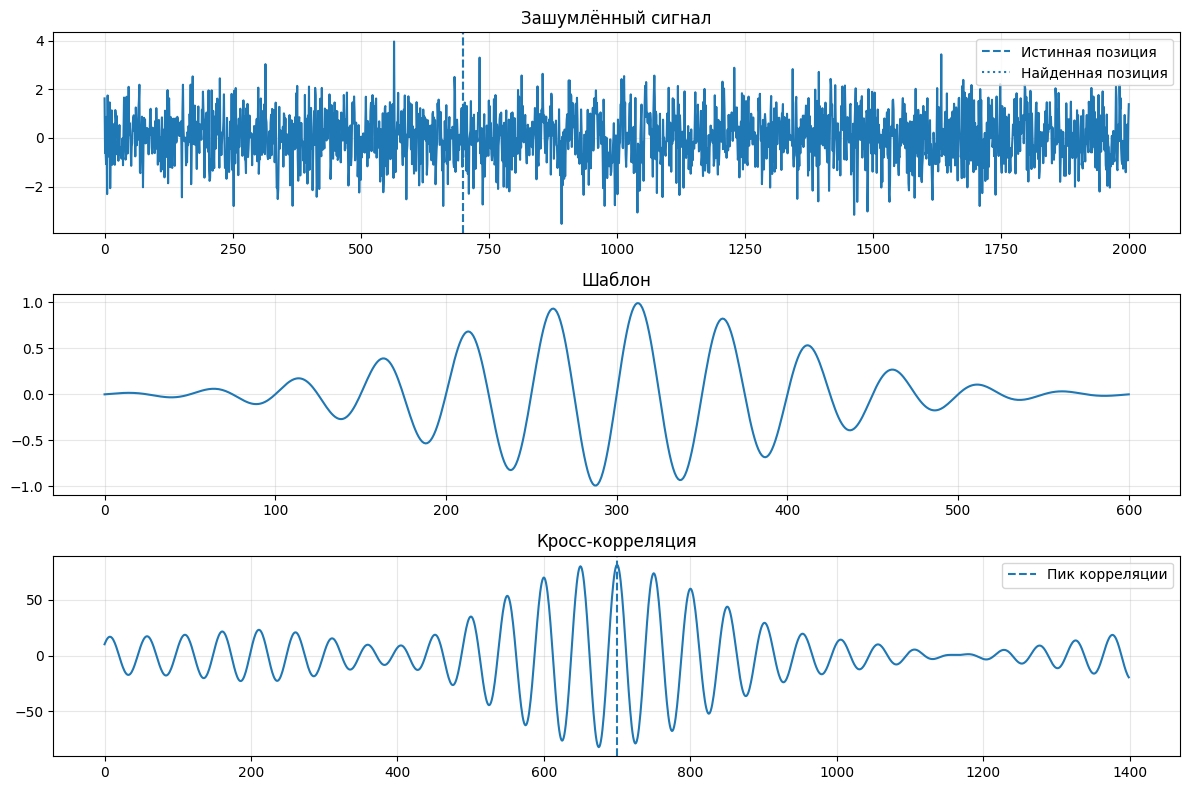

A | SNR (дБ) | mean_error | success_rate
0.20 |   -22.29 |     180.15 |        0.07
0.45 |   -15.20 |      36.05 |        0.30
0.71 |   -11.35 |      19.35 |        0.55
0.96 |    -8.69 |       9.22 |        0.82
1.21 |    -6.65 |       3.08 |        0.95
1.46 |    -5.01 |       1.65 |        0.97
1.72 |    -3.62 |       0.28 |        1.00
1.97 |    -2.43 |       0.23 |        1.00
2.22 |    -1.38 |       0.20 |        1.00
2.47 |    -0.45 |       0.20 |        1.00
2.73 |     0.40 |       0.07 |        1.00
2.98 |     1.17 |       0.10 |        1.00
3.23 |     1.87 |       0.05 |        1.00
3.48 |     2.53 |       0.03 |        1.00
3.74 |     3.14 |       0.03 |        1.00
3.99 |     3.70 |       0.00 |        1.00
4.24 |     4.24 |       0.00 |        1.00
4.49 |     4.74 |       0.00 |        1.00
4.75 |     5.22 |       0.00 |        1.00
5.00 |     5.67 |       0.00 |        1.00


In [9]:
# Задание 4
np.random.seed(42)

fs = 1000
sigma = 100
n_template = 6 * sigma + 1
tt = np.arange(n_template) - n_template // 2

template = np.exp(-(tt**2) / (2 * sigma**2)) * np.sin(2 * np.pi * 20 * tt / fs)

N = 2000
A_values = np.linspace(0.2, 5, 20)

snr_values = []
mean_errors = []
success_rates = []

for A in A_values:
    trial_errors = []
    for _ in range(40):
        position = np.random.randint(200, N - n_template - 200)
        noise = np.random.randn(N)
        long_signal = noise.copy()
        long_signal[position:position + n_template] += A * template

        corr = np.correlate(long_signal, template, mode='valid')
        peak_idx = np.argmax(corr)
        trial_errors.append(abs(peak_idx - position))

    signal_power = np.mean((A * template) ** 2)
    noise_power = 1.0
    snr = 10 * np.log10(signal_power / noise_power)

    snr_values.append(snr)
    mean_errors.append(np.mean(trial_errors))
    success_rates.append(np.mean(np.array(trial_errors) <= 2))

plt.figure(figsize=(10, 5))
plt.plot(snr_values, mean_errors, 'o-')
plt.xlabel('SNR, дБ')
plt.ylabel('Средняя ошибка локализации')
plt.title('Точность обнаружения шаблона при разных SNR')
plt.grid(alpha=0.3)
plt.show()

# Один показательный пример
A_demo = 1.0
np.random.seed(1)
position = 700
noise = np.random.randn(N)
long_signal = noise.copy()
long_signal[position:position + n_template] += A_demo * template

corr = np.correlate(long_signal, template, mode='valid')
peak_idx = np.argmax(corr)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(long_signal)
plt.axvline(position, linestyle='--', label='Истинная позиция')
plt.axvline(peak_idx, linestyle=':', label='Найденная позиция')
plt.title('Зашумлённый сигнал')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(template)
plt.title('Шаблон')
plt.grid(alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(corr)
plt.axvline(peak_idx, linestyle='--', label='Пик корреляции')
plt.title('Кросс-корреляция')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print('A | SNR (дБ) | mean_error | success_rate')
for A, snr, err, rate in zip(A_values, snr_values, mean_errors, success_rates):
    print(f'{A:>4.2f} | {snr:>8.2f} | {err:>10.2f} | {rate:>11.2f}')

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

Резкое ухудшение начинается в области низких SNR, примерно ниже −11…−15 дБ. 
В этом диапазоне шум уже часто маскирует шаблон, поэтому максимум корреляции заметно чаще указывает не на истинную позицию, а на случайный участок сигнала.

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [19]:
# Подготовка файлов для задания 5
from pathlib import Path

possible_full = [
    Path('full_audio.wav'),
    Path('data/full_audio.wav'),
]
possible_frag = [
    Path('fragment.wav'),
    Path('data/fragment.wav'),
]

full_path = next((p for p in possible_full if p.exists()), None)
frag_path = next((p for p in possible_frag if p.exists()), None)

if full_path is None or frag_path is None:
    raise FileNotFoundError(
        'Не удалось найти full_audio.wav и/или fragment.wav. '
        'Положите их в текущую папку или в папку data.'
    )

print('Найден full_audio:', full_path)
print('Найден fragment:', frag_path)


Найден full_audio: full_audio.wav
Найден fragment: fragment.wav


C:\Users\tooly\AppData\Local\Temp\ipykernel_8508\1191506929.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full = wavfile.read(str(full_path))
C:\Users\tooly\AppData\Local\Temp\ipykernel_8508\1191506929.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, frag = wavfile.read(str(frag_path))


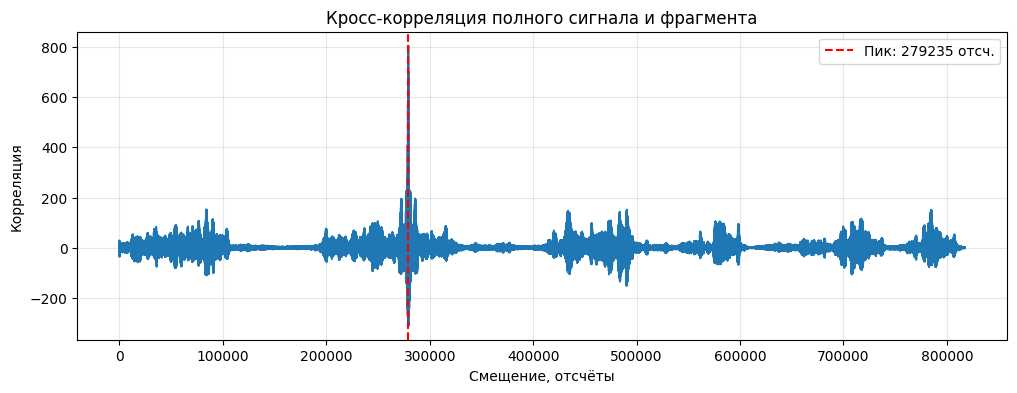

Найденная позиция: 279235 отсчётов
Время начала: 6.332 c
Длительность фрагмента: 1.279 c
Оригинальный фрагмент:


Найденный участок:


In [20]:
# Задание 5
fs_full, full = wavfile.read(str(full_path))
fs_frag, frag = wavfile.read(str(frag_path))

# Если аудио стерео, переводим в моно
if full.ndim > 1:
    full = full.mean(axis=1)

if frag.ndim > 1:
    frag = frag.mean(axis=1)

full = full.astype(np.float32)
frag = frag.astype(np.float32)

# Нормализация
full = full / np.max(np.abs(full))
frag = frag / np.max(np.abs(frag))

# Кросс-корреляция
corr = signal.correlate(full, frag, mode='valid')
peak_idx = np.argmax(corr)
peak_time = peak_idx / fs_full

matched = full[peak_idx:peak_idx + len(frag)]

plt.figure(figsize=(12, 4))
plt.plot(corr)
plt.axvline(peak_idx, color='r', linestyle='--', label=f'Пик: {peak_idx} отсч.')
plt.title('Кросс-корреляция полного сигнала и фрагмента')
plt.xlabel('Смещение, отсчёты')
plt.ylabel('Корреляция')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'Найденная позиция: {peak_idx} отсчётов')
print(f'Время начала: {peak_time:.3f} c')
print(f'Длительность фрагмента: {len(frag) / fs_frag:.3f} c')

print('Оригинальный фрагмент:')
display(Audio(data=frag.astype(np.float32), rate=fs_frag))

print('Найденный участок:')
display(Audio(data=matched.astype(np.float32), rate=fs_full))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

- Нормализация убирает влияние амплитуды сигнала, чтобы корреляция зависела от формы, а не от громкости. Это делает поиск совпадений более корректным.
- Фрагмент может встречаться несколько раз, и каждому совпадению соответствует пик на графике корреляции.
Корреляция позволяет находить такие позиции, но при похожих участках сигнала могут появляться ложные максимумы.
- Корреляция всё равно даст максимум, но он будет значительно ниже и не будет явно выделяться. В этом случае определить наличие фрагмента надёжно нельзя.